<a href="https://colab.research.google.com/github/kalana-mihiranga/Ensemble-Framework-for-Deepfake-Face-Detection/blob/second/part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub
!pip install timm
!pip install scikit-learn
!pip install matplotlib seaborn

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import shutil

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

In [ ]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "prithivsakthiur/deepfake-vs-real-20k"
)

print("Dataset path:", path)

100%|██████████| 10.9G/10.9G [04:47<00:00, 40.8MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/prithivsakthiur/deepfake-vs-real-20k/versions/1


In [ ]:
path2 = kagglehub.dataset_download(
    "xhlulu/140k-real-and-fake-faces"
)

print("Dataset 2 path:", path2)

Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
Dataset 2 path: /kaggle/input/140k-real-and-fake-faces


In [ ]:
dataset1_path = "/root/.cache/kagglehub/datasets/prithivsakthiur/deepfake-vs-real-20k/versions/1/Deep-vs-Real"

real1 = os.path.join(dataset1_path, "Real")
fake1 = os.path.join(dataset1_path, "Deepfake")

In [ ]:
dataset2_path = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"

train2 = os.path.join(dataset2_path, "train")
valid2 = os.path.join(dataset2_path, "valid")
test2 = os.path.join(dataset2_path, "test")

In [ ]:
real1_count = len(os.listdir(real1))
fake1_count = len(os.listdir(fake1))

print("Dataset 1")
print("Real:", real1_count)
print("Fake:", fake1_count)

Dataset 1
Real: 9643
Fake: 9576


In [ ]:
def count_images(folder):

    real = len(os.listdir(os.path.join(folder, "real")))
    fake = len(os.listdir(os.path.join(folder, "fake")))

    return real, fake

train_real2, train_fake2 = count_images(train2)
val_real2, val_fake2 = count_images(valid2)
test_real2, test_fake2 = count_images(test2)

print("Dataset 2")
print("Train:", train_real2, train_fake2)
print("Val:", val_real2, val_fake2)
print("Test:", test_real2, test_fake2)

Dataset 2
Train: 50000 50000
Val: 10000 10000
Test: 10000 10000


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

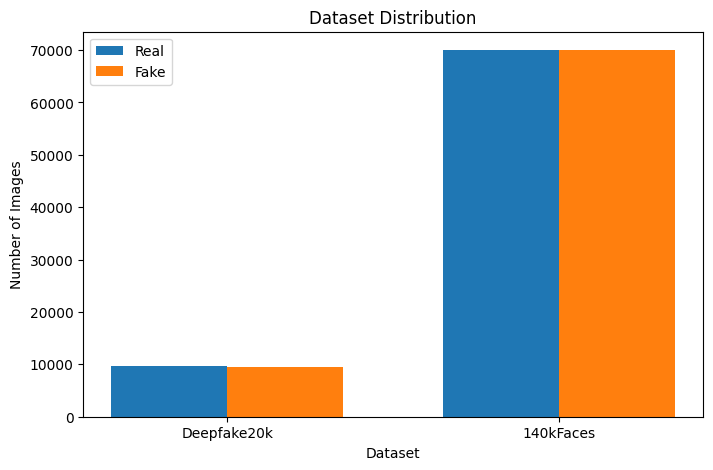

In [ ]:
datasets = ["Deepfake20k", "140kFaces"]

real_counts = [
    real1_count,
    train_real2 + val_real2 + test_real2
]

fake_counts = [
    fake1_count,
    train_fake2 + val_fake2 + test_fake2
]

x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, real_counts, width, label="Real")
plt.bar(x + width/2, fake_counts, width, label="Fake")

plt.xlabel("Dataset")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")

plt.xticks(x, datasets)
plt.legend()

plt.show()

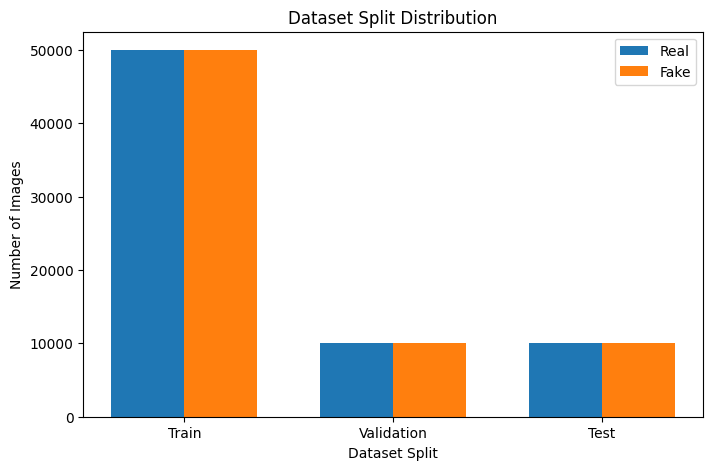

In [ ]:
splits = ["Train","Validation","Test"]

real_counts = [train_real2, val_real2, test_real2]
fake_counts = [train_fake2, val_fake2, test_fake2]

x = np.arange(len(splits))

plt.figure(figsize=(8,5))

plt.bar(x - width/2, real_counts, width, label="Real")
plt.bar(x + width/2, fake_counts, width, label="Fake")

plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.title("Dataset Split Distribution")

plt.xticks(x, splits)

plt.legend()

plt.show()

In [ ]:
from PIL import Image
import random

In [ ]:
def show_samples(folder, title):

    images = random.sample(os.listdir(folder), 5)

    plt.figure(figsize=(12,3))

    for i, img_name in enumerate(images):

        img = Image.open(os.path.join(folder, img_name))

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

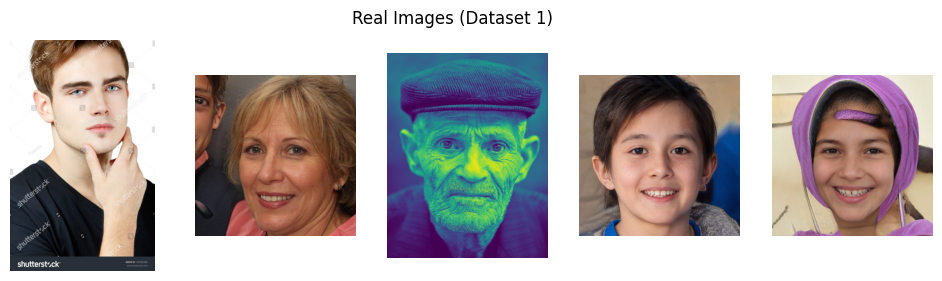

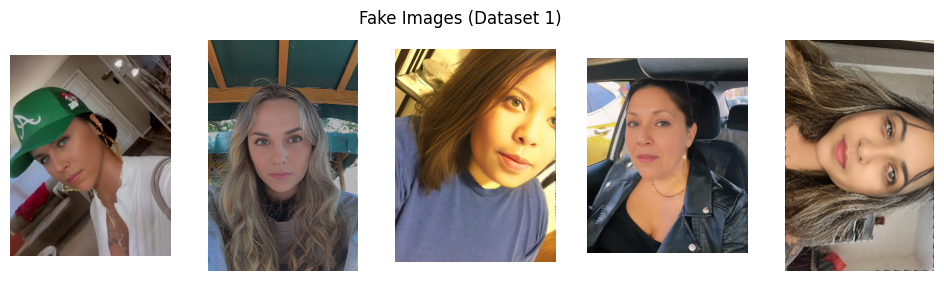

In [ ]:
show_samples(real1, "Real Images (Dataset 1)")
show_samples(fake1, "Fake Images (Dataset 1)")

In [ ]:
from PIL import Image
import numpy as np

In [ ]:
def get_sizes(folder, sample=500):

    files = random.sample(os.listdir(folder), min(sample, len(os.listdir(folder))))

    widths = []
    heights = []

    for f in files:

        img = Image.open(os.path.join(folder, f))

        w,h = img.size

        widths.append(w)
        heights.append(h)

    return widths, heights

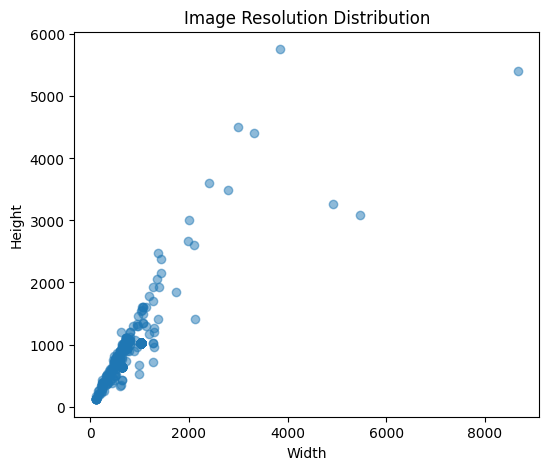

In [ ]:
w,h = get_sizes(real1)

plt.figure(figsize=(6,5))

plt.scatter(w,h, alpha=0.5)

plt.xlabel("Width")
plt.ylabel("Height")

plt.title("Image Resolution Distribution")

plt.show()

In [ ]:
!pip install kagglehub
!pip install timm
!pip install scikit-learn
!pip install matplotlib seaborn

In [ ]:
import os
import random
import numpy as np
import shutil
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, ConcatDataset

from sklearn.model_selection import train_test_split

import kagglehub

In [ ]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [ ]:
path1 = kagglehub.dataset_download(
    "prithivsakthiur/deepfake-vs-real-20k"
)

print("Dataset1:", path1)

path2 = kagglehub.dataset_download(
    "xhlulu/140k-real-and-fake-faces"
)

print("Dataset2:", path2)

Using Colab cache for faster access to the 'deepfake-vs-real-20k' dataset.
Dataset1: /kaggle/input/deepfake-vs-real-20k
Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
Dataset2: /kaggle/input/140k-real-and-fake-faces


In [ ]:
dataset1 = "/root/.cache/kagglehub/datasets/prithivsakthiur/deepfake-vs-real-20k/versions/1/Deep-vs-Real"

real1 = os.path.join(dataset1, "Real")
fake1 = os.path.join(dataset1, "Deepfake")

In [ ]:
dataset2 = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"

train2 = os.path.join(dataset2, "train")
val2 = os.path.join(dataset2, "valid")
test2 = os.path.join(dataset2, "test")

In [ ]:
combined = "/content/combined_dataset"

for split in ["train","val","test"]:

    os.makedirs(os.path.join(combined, split, "real"), exist_ok=True)
    os.makedirs(os.path.join(combined, split, "fake"), exist_ok=True)

In [ ]:
real_images = os.listdir(real1)
fake_images = os.listdir(fake1)

train_real, temp_real = train_test_split(
    real_images, test_size=0.30, random_state=42
)

train_fake, temp_fake = train_test_split(
    fake_images, test_size=0.30, random_state=42
)

val_real, test_real = train_test_split(
    temp_real, test_size=0.5, random_state=42
)

val_fake, test_fake = train_test_split(
    temp_fake, test_size=0.5, random_state=42
)

In [ ]:
def copy_files(files, source, destination):

    for f in files:

        shutil.copy(
            os.path.join(source, f),
            os.path.join(destination, f)
        )

In [ ]:
copy_files(train_real, real1, os.path.join(combined,"train","real"))
copy_files(train_fake, fake1, os.path.join(combined,"train","fake"))

copy_files(val_real, real1, os.path.join(combined,"val","real"))
copy_files(val_fake, fake1, os.path.join(combined,"val","fake"))

copy_files(test_real, real1, os.path.join(combined,"test","real"))
copy_files(test_fake, fake1, os.path.join(combined,"test","fake"))

In [ ]:
def copy_folder(src, dst):

    for file in os.listdir(src):

        shutil.copy(
            os.path.join(src,file),
            os.path.join(dst,file)
        )

In [ ]:
copy_folder(os.path.join(train2,"real"), os.path.join(combined,"train","real"))
copy_folder(os.path.join(train2,"fake"), os.path.join(combined,"train","fake"))

copy_folder(os.path.join(val2,"real"), os.path.join(combined,"val","real"))
copy_folder(os.path.join(val2,"fake"), os.path.join(combined,"val","fake"))

copy_folder(os.path.join(test2,"real"), os.path.join(combined,"test","real"))
copy_folder(os.path.join(test2,"fake"), os.path.join(combined,"test","fake"))

In [ ]:
for split in ["train","val","test"]:

    real_count = len(os.listdir(os.path.join(combined, split, "real")))
    fake_count = len(os.listdir(os.path.join(combined, split, "fake")))

    print(split, "Real:", real_count, "Fake:", fake_count)

train Real: 56750 Fake: 56703
val Real: 11446 Fake: 11436
test Real: 11447 Fake: 11437


In [ ]:
splits = ["train","val","test"]

real_counts = []
fake_counts = []

for s in splits:

    real_counts.append(len(os.listdir(os.path.join(combined,s,"real"))))
    fake_counts.append(len(os.listdir(os.path.join(combined,s,"fake"))))

x = np.arange(len(splits))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2, real_counts, width, label="Real")
plt.bar(x+width/2, fake_counts, width, label="Fake")

plt.xticks(x,splits)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

plt.title("Combined Dataset Distribution")

plt.legend()

plt.show()

In [ ]:
from PIL import Image

def show_samples(folder):

    imgs = random.sample(os.listdir(folder),5)

    plt.figure(figsize=(12,3))

    for i,img in enumerate(imgs):

        image = Image.open(os.path.join(folder,img))

        plt.subplot(1,5,i+1)
        plt.imshow(image)
        plt.axis("off")

    plt.show()

    show_samples(os.path.join(combined,"train","real"))
show_samples(os.path.join(combined,"train","fake"))

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((224,224)),
    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

train_dataset = datasets.ImageFolder(
    os.path.join(combined,"train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(combined,"val"),
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(combined,"test"),
    transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
import os

dataset_path = os.path.join(path, "Deep-vs-Real")

real_path = os.path.join(dataset_path, "Real")
fake_path = os.path.join(dataset_path, "Deepfake")

print("Real images:", len(os.listdir(real_path)))
print("Fake images:", len(os.listdir(fake_path)))

Real images: 9643
Fake images: 9576


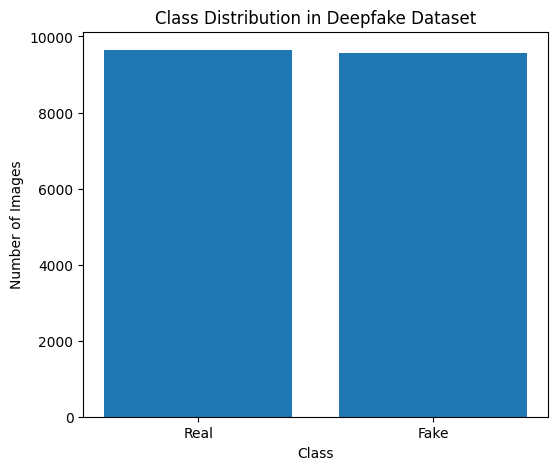

In [ ]:
import matplotlib.pyplot as plt

real_count = len(os.listdir(real_path))
fake_count = len(os.listdir(fake_path))

classes = ["Real", "Fake"]
counts = [real_count, fake_count]

plt.figure(figsize=(6,5))

plt.bar(classes, counts)

plt.title("Class Distribution in Deepfake Dataset")
plt.ylabel("Number of Images")
plt.xlabel("Class")

plt.show()

In [ ]:
from PIL import Image
import random
def show_samples(folder, title):

    images = random.sample(os.listdir(folder), 5)

    plt.figure(figsize=(12,3))

    for i, img_name in enumerate(images):

        img = Image.open(os.path.join(folder, img_name))

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

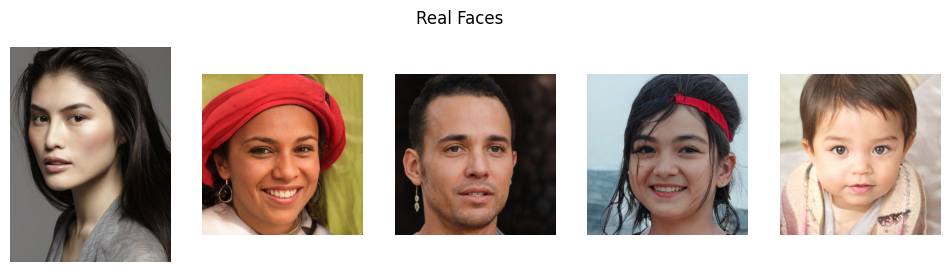

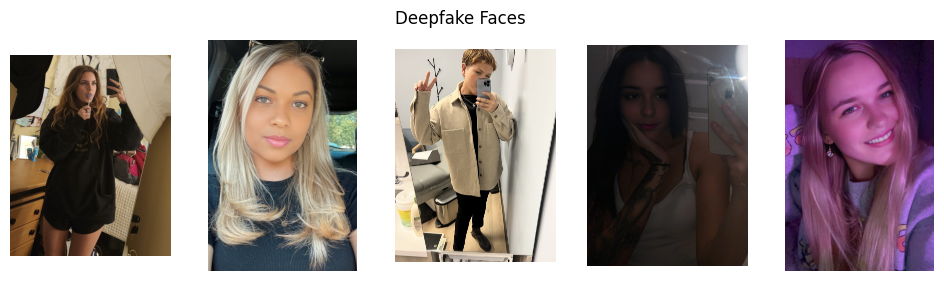

In [ ]:
show_samples(real_path, "Real Faces")
show_samples(fake_path, "Deepfake Faces")

In [ ]:
import numpy as np
def get_image_sizes(folder, sample_size=500):

    files = random.sample(os.listdir(folder), min(sample_size, len(os.listdir(folder))))

    widths = []
    heights = []

    for f in files:

        img = Image.open(os.path.join(folder, f))
        w, h = img.size

        widths.append(w)
        heights.append(h)

    return widths, heights

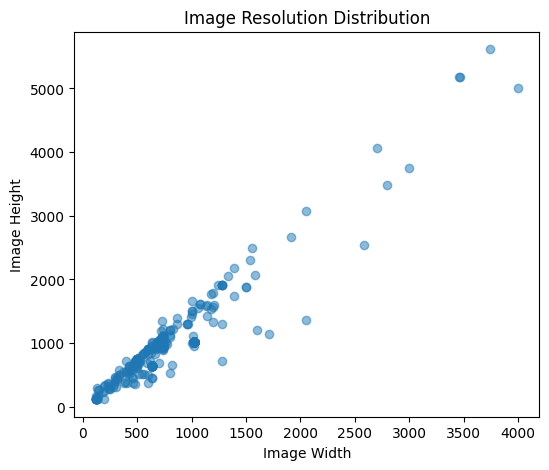

In [ ]:
widths, heights = get_image_sizes(real_path)
plt.figure(figsize=(6,5))

plt.scatter(widths, heights, alpha=0.5)

plt.xlabel("Image Width")
plt.ylabel("Image Height")

plt.title("Image Resolution Distribution")

plt.show()

In [ ]:
print("Mean Width:", np.mean(widths))
print("Mean Height:", np.mean(heights))

print("Min Width:", np.min(widths))
print("Min Height:", np.min(heights))

print("Max Width:", np.max(widths))
print("Max Height:", np.max(heights))

Mean Width: 882.556
Mean Height: 990.168
Min Width: 118
Min Height: 118
Max Width: 4000
Max Height: 5616


In [ ]:
def check_corrupted(folder):

    corrupted = []

    for file in os.listdir(folder):

        try:
            img = Image.open(os.path.join(folder, file))
            img.verify()

        except:
            corrupted.append(file)

    return corrupted

In [ ]:
corrupted_real = check_corrupted(real_path)
corrupted_fake = check_corrupted(fake_path)

print("Corrupted real images:", len(corrupted_real))
print("Corrupted fake images:", len(corrupted_fake))

Corrupted real images: 0
Corrupted fake images: 0


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
import timm

model = timm.create_model(
    "xception",
    pretrained=True,
    num_classes=1
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth


In [ ]:
import torch.nn as nn

in_features = model.get_classifier().in_features

model.reset_classifier(0)

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 1)
)

model = model.to(device)

In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

Trainable parameters: 524801
Total parameters: 21331753


In [ ]:
criterion = nn.BCEWithLogitsLoss()

In [ ]:
# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [ ]:
import timm
import torch.nn as nn

model = timm.create_model(
    "xception",
    pretrained=True
)

in_features = model.get_classifier().in_features

model.reset_classifier(num_classes=0)

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 1)
)

model = model.to(device)

In [ ]:
dummy = torch.randn(1,3,224,224).to(device)

out = model(dummy)

print(out.shape)

torch.Size([1, 2048])


In [ ]:
import timm
import torch.nn as nn

# Load backbone
model = timm.create_model(
    "xception",
    pretrained=True,
    num_classes=0   # IMPORTANT → removes original classifier
)

# Feature size from backbone
in_features = model.num_features

# Add our classifier
model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 1)
)

model = model.to(device)

In [ ]:
dummy = torch.randn(1,3,224,224).to(device)

out = model(dummy)

print(out.shape)

torch.Size([1, 2048])


In [ ]:
import timm
import torch.nn as nn

# Load backbone without classifier
backbone = timm.create_model(
    "xception",
    pretrained=True,
    num_classes=0
)

backbone = backbone.to(device)

In [ ]:
class DeepfakeXception(nn.Module):

    def __init__(self, backbone):
        super().__init__()

        self.backbone = backbone

        self.classifier = nn.Sequential(
            nn.Linear(backbone.num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

    def forward(self, x):

        features = self.backbone(x)

        output = self.classifier(features)

        return output

In [ ]:
model = DeepfakeXception(backbone)

model = model.to(device)

In [ ]:
dummy = torch.randn(1,3,224,224).to(device)

out = model(dummy)

print(out.shape)

torch.Size([1, 1])


In [ ]:
for param in model.backbone.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [ ]:
images, labels = next(iter(train_loader))

images = images.to(device)

test_out = model(images)

print("Model output:", test_out.shape)

Model output: torch.Size([32, 1])


In [ ]:
criterion = nn.BCEWithLogitsLoss()

In [ ]:
optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [ ]:
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Train images: 113453
Validation images: 22882
Test images: 22884


In [ ]:
from collections import Counter

train_labels = [label for _, label in train_dataset.samples]

label_counts = Counter(train_labels)

print("Train distribution:")
print("Real:", label_counts[0])
print("Fake:", label_counts[1])

Train distribution:
Real: 56703
Fake: 56750


In [ ]:
num_epochs = 10
best_val_loss = float("inf")

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ----- Validation -----

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print("Train Loss:", train_loss)
    print("Val Loss:", val_loss)
    print("--------------------------")

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(model.state_dict(), "cnn_xception_best.pth")

Epoch 1/10
Train Loss: 0.5379525293284597
Val Loss: 0.5172453768988395
--------------------------
Epoch 2/10
Train Loss: 0.4893320013894513
Val Loss: 0.4728631846315368
--------------------------
Epoch 3/10
Train Loss: 0.4711036284596518
Val Loss: 0.43478551474738053
--------------------------
Epoch 4/10
Train Loss: 0.45446520126007134
Val Loss: 0.41877576061550464
--------------------------
Epoch 5/10
Train Loss: 0.44541047719394966
Val Loss: 0.4164692502645724
--------------------------
Epoch 6/10
Train Loss: 0.4366957057021596
Val Loss: 0.41940379427360924
--------------------------
Epoch 7/10
Train Loss: 0.43131986829818336
Val Loss: 0.40283759402412944
--------------------------
Epoch 8/10
Train Loss: 0.42513919566236374
Val Loss: 0.3984515124973555
--------------------------
Epoch 9/10
Train Loss: 0.42216684825159506
Val Loss: 0.42506423214315203
--------------------------
Epoch 10/10
Train Loss: 0.41627520140842467
Val Loss: 0.3913836284910001
--------------------------


In [ ]:
model.load_state_dict(torch.load("cnn_xception_best.pth"))
model.eval()

print("Best CNN model loaded.")

Best CNN model loaded.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        all_preds.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

In [ ]:
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels)

binary_preds = (all_preds > 0.5).astype(int)

In [ ]:
accuracy = accuracy_score(all_labels, binary_preds)
precision = precision_score(all_labels, binary_preds)
recall = recall_score(all_labels, binary_preds)
f1 = f1_score(all_labels, binary_preds)
auc = roc_auc_score(all_labels, all_preds)

print("CNN Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC:", auc)

CNN Results
Accuracy: 0.8215346967313407
Precision: 0.8054933200564268
Recall: 0.8479951078885297
F1 Score: 0.8261979742956848
AUC: 0.9057804859524993


In [ ]:
np.save("cnn_test_probs.npy", all_preds)
np.save("cnn_test_labels.npy", all_labels)

print("CNN predictions saved.")

CNN predictions saved.


In [ ]:
import torch

torch.save(model.state_dict(), "cnn_xception_model.pth")

print("CNN model saved.")

CNN model saved.


In [ ]:
from google.colab import files

files.download("cnn_xception_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import zipfile

files_to_zip = [
    "cnn_xception_model.pth",
    "cnn_test_probs.npy",
    "cnn_test_labels.npy"
]

with zipfile.ZipFile("cnn_model_outputs.zip", "w") as z:

    for file in files_to_zip:
        z.write(file)

print("ZIP created.")
files.download("cnn_model_outputs.zip")

ZIP created.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image
from scipy.fftpack import dct
import numpy as np
import os

In [ ]:
def dct2(image):

    return dct(
        dct(image.T, norm='ortho').T,
        norm='ortho'
    )

In [ ]:
def extract_dct_features(folder_path, label, max_images=None):

    features = []
    labels = []

    files = os.listdir(folder_path)

    if max_images:
        files = files[:max_images]

    for file in files:

        img_path = os.path.join(folder_path, file)

        try:

            img = Image.open(img_path).convert("L")
            img = img.resize((128,128))

            img_array = np.array(img)

            dct_coeff = dct2(img_array)

            dct_low = dct_coeff[:20,:20]

            features.append(dct_low.flatten())
            labels.append(label)

        except:
            continue

    return features, labels

In [ ]:
data_path = combined

In [ ]:
train_real_features, train_real_labels = extract_dct_features(
    os.path.join(data_path,"train","real"),
    label=0
)

In [ ]:
train_fake_features, train_fake_labels = extract_dct_features(
    os.path.join(data_path,"train","fake"),
    label=1
)

In [ ]:
X_train = np.array(train_real_features + train_fake_features)
y_train = np.array(train_real_labels + train_fake_labels)

print("Training features:", X_train.shape)

Training features: (113453, 400)


In [ ]:
val_real_features, val_real_labels = extract_dct_features(
    os.path.join(data_path,"val","real"),
    label=0
)

val_fake_features, val_fake_labels = extract_dct_features(
    os.path.join(data_path,"val","fake"),
    label=1
)

X_val = np.array(val_real_features + val_fake_features)
y_val = np.array(val_real_labels + val_fake_labels)

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=2000)

clf.fit(X_train, y_train)

print("DCT model trained.")

DCT model trained.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

val_probs = clf.predict_proba(X_val)[:,1]

val_preds = (val_probs > 0.5).astype(int)

print("DCT Validation Results")
print("Accuracy:", accuracy_score(y_val, val_preds))
print("Precision:", precision_score(y_val, val_preds))
print("Recall:", recall_score(y_val, val_preds))
print("F1:", f1_score(y_val, val_preds))
print("AUC:", roc_auc_score(y_val, val_probs))

DCT Validation Results
Accuracy: 0.663053928852373
Precision: 0.6588506139154161
Recall: 0.6756733123469745
F1: 0.667155931618028
AUC: 0.7185801195412044


In [ ]:
test_real_features, test_real_labels = extract_dct_features(
    os.path.join(data_path,"test","real"),
    label=0
)

test_fake_features, test_fake_labels = extract_dct_features(
    os.path.join(data_path,"test","fake"),
    label=1
)

X_test = np.array(test_real_features + test_fake_features)
y_test = np.array(test_real_labels + test_fake_labels)

test_probs = clf.predict_proba(X_test)[:,1]

In [ ]:
np.save("dct_test_probs.npy", test_probs)
np.save("dct_test_labels.npy", y_test)

print("DCT predictions saved.")

DCT predictions saved.


In [ ]:
import joblib

joblib.dump(clf, "dct_model.pkl")

print("DCT model saved.")

from google.colab import files

files.download("dct_model.pkl")

DCT model saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import numpy as np

def get_patch_predictions(loader, model, device):

    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            batch_probs = []

            for img in images:

                patches = []

                patches.append(img[:,0:112,0:112])
                patches.append(img[:,0:112,112:224])
                patches.append(img[:,112:224,0:112])
                patches.append(img[:,112:224,112:224])

                patches = torch.stack(patches).to(device)

                outputs = model(patches)

                probs = torch.sigmoid(outputs)

                avg_prob = probs.mean().item()

                batch_probs.append(avg_prob)

            all_probs.extend(batch_probs)
            all_labels.extend(labels.cpu().numpy().flatten())

    return np.array(all_probs), np.array(all_labels)

In [ ]:
patch_test_probs, patch_test_labels = get_patch_predictions(
    test_loader,
    model,
    device
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

patch_preds = (patch_test_probs > 0.5).astype(int)

print("Patch Model Results")
print("Accuracy:", accuracy_score(patch_test_labels, patch_preds))
print("Precision:", precision_score(patch_test_labels, patch_preds))
print("Recall:", recall_score(patch_test_labels, patch_preds))
print("F1:", f1_score(patch_test_labels, patch_preds))
print("AUC:", roc_auc_score(patch_test_labels, patch_test_probs))

Patch Model Results
Accuracy: 0.610907184058731
Precision: 0.5708317085399142
Recall: 0.8951690399231239
F1: 0.6971222532145044
AUC: 0.7049490259036519


In [ ]:
cnn_probs = np.load("cnn_test_probs.npy")
dct_probs = np.load("dct_test_probs.npy")

patch_probs = patch_test_probs

y_test = np.load("cnn_test_labels.npy")

In [ ]:
X_meta = np.column_stack((cnn_probs, dct_probs, patch_probs))

print("Meta feature shape:", X_meta.shape)

Meta feature shape: (22884, 3)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=4,
    random_state=42
)

rf.fit(X_meta, y_test)

RandomForestClassifier(max_depth=4, n_estimators=150, random_state=42)

In [ ]:
rf_probs = rf.predict_proba(X_meta)[:,1]

rf_preds = (rf_probs > 0.5).astype(int)

In [ ]:
print("Ensemble Results")

print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1:", f1_score(y_test, rf_preds))
print("AUC:", roc_auc_score(y_test, rf_probs))

Ensemble Results
Accuracy: 0.8470984093689914
Precision: 0.8476207137858642
Recall: 0.846510002620774
F1: 0.8470649940993925
AUC: 0.9201838278453269


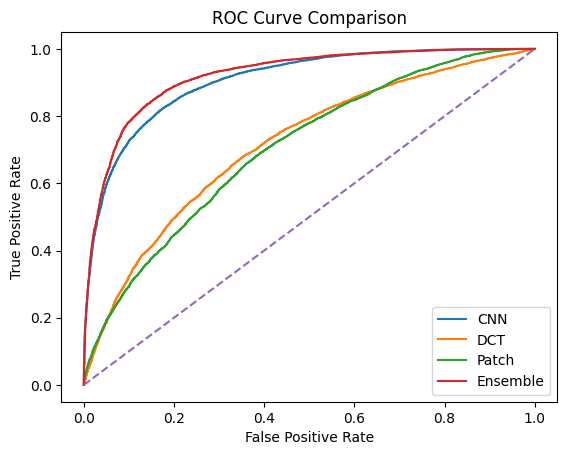

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_cnn, tpr_cnn, _ = roc_curve(y_test, cnn_probs)
fpr_dct, tpr_dct, _ = roc_curve(y_test, dct_probs)
fpr_patch, tpr_patch, _ = roc_curve(y_test, patch_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure()

plt.plot(fpr_cnn, tpr_cnn, label="CNN")
plt.plot(fpr_dct, tpr_dct, label="DCT")
plt.plot(fpr_patch, tpr_patch, label="Patch")
plt.plot(fpr_rf, tpr_rf, label="Ensemble")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

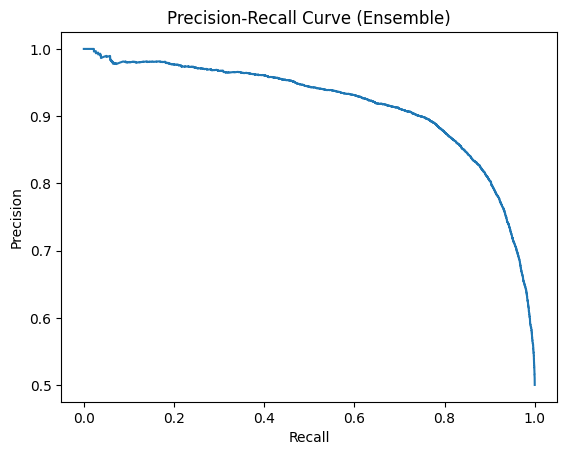

In [ ]:
from sklearn.metrics import precision_recall_curve

prec, rec, _ = precision_recall_curve(y_test, rf_probs)

plt.figure()

plt.plot(rec, prec)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve (Ensemble)")

plt.show()

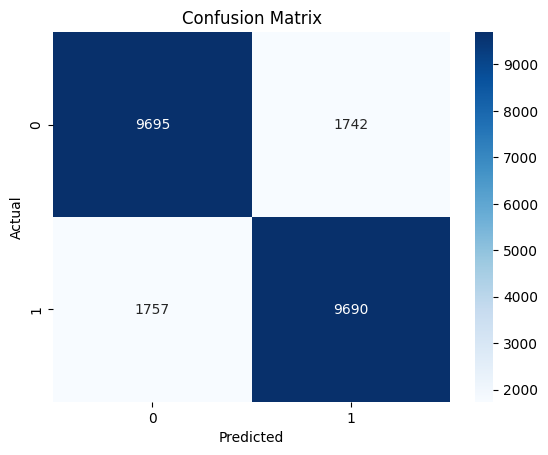

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_preds)

plt.figure()

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

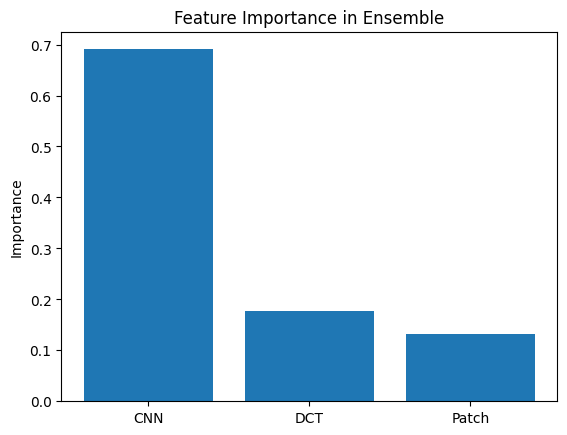

In [ ]:
features = ["CNN","DCT","Patch"]

importances = rf.feature_importances_

plt.figure()

plt.bar(features, importances)

plt.ylabel("Importance")

plt.title("Feature Importance in Ensemble")

plt.show()

In [ ]:
import joblib

torch.save(model.state_dict(),"cnn_model.pth")

joblib.dump(clf,"dct_model.pkl")

joblib.dump(rf,"ensemble_model.pkl")

['ensemble_model.pkl']

In [ ]:
import json

results = {

"CNN_AUC": float(roc_auc_score(y_test, cnn_probs)),
"DCT_AUC": float(roc_auc_score(y_test, dct_probs)),
"PATCH_AUC": float(roc_auc_score(y_test, patch_probs)),
"ENSEMBLE_AUC": float(roc_auc_score(y_test, rf_probs))

}

with open("results.json","w") as f:
    json.dump(results,f,indent=4)

In [ ]:
from google.colab import files

files.download("cnn_model.pth")
files.download("dct_model.pkl")
files.download("ensemble_model.pkl")
files.download("results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
cnn_val_probs = []
cnn_val_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        cnn_val_probs.extend(probs.cpu().numpy())
        cnn_val_labels.extend(labels.numpy())

cnn_val_probs = np.array(cnn_val_probs).flatten()
cnn_val_labels = np.array(cnn_val_labels)

In [ ]:
np.save("cnn_val_probs.npy", cnn_val_probs)
np.save("cnn_val_labels.npy", cnn_val_labels)

In [ ]:
patch_val_probs, patch_val_labels = get_patch_predictions(
    val_loader,
    model,
    device
)

In [ ]:
val_real_features, val_real_labels = extract_dct_features(
    os.path.join(data_path,"val","real"),
    label=0
)

val_fake_features, val_fake_labels = extract_dct_features(
    os.path.join(data_path,"val","fake"),
    label=1
)

X_val = np.array(val_real_features + val_fake_features)
y_val = np.array(val_real_labels + val_fake_labels)

dct_val_probs = clf.predict_proba(X_val)[:,1]

In [ ]:
X_val_meta = np.column_stack((
    cnn_val_probs,
    dct_val_probs,
    patch_val_probs
))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=4,
    random_state=42
)

rf.fit(X_val_meta, y_val)

RandomForestClassifier(max_depth=4, n_estimators=150, random_state=42)

In [ ]:
cnn_test = np.load("cnn_test_probs.npy")
dct_test = np.load("dct_test_probs.npy")
patch_test = patch_test_probs

X_test_meta = np.column_stack((cnn_test, dct_test, patch_test))

rf_probs = rf.predict_proba(X_test_meta)[:,1]
rf_preds = (rf_probs > 0.5).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Final Ensemble Results")

print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1:", f1_score(y_test, rf_preds))
print("AUC:", roc_auc_score(y_test, rf_probs))

Final Ensemble Results
Accuracy: 0.8443890928159413
Precision: 0.8463024767258036
Recall: 0.8417926094173146
F1: 0.8440415188542898
AUC: 0.917909347220276


In [ ]:
import kagglehub

unseen_path = kagglehub.dataset_download(
    "muhammadbilal6305/200k-real-vs-ai-visuals-by-mbilal"
)

print("Dataset path:", unseen_path)

100%|██████████| 1.82G/1.82G [00:46<00:00, 41.7MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/muhammadbilal6305/200k-real-vs-ai-visuals-by-mbilal/versions/4


In [ ]:
import os

print(os.listdir(unseen_path))

['my_real_vs_ai_dataset', 'train_labels.csv', 'test_labels.csv', 'val_labels.csv']


In [ ]:
dataset_root = os.path.join(unseen_path, "my_real_vs_ai_dataset")

print(os.listdir(dataset_root)[:10])

['my_real_vs_ai_dataset']


In [ ]:
import pandas as pd

labels_df = pd.read_csv(os.path.join(unseen_path, "test_labels.csv"))

print(labels_df.head())

   Unnamed: 0         filename  label resolution  image_size
0           0        34551.jpg      1    256x256       65536
1           1        39572.jpg      1    256x256       65536
2           2  real_299_11.jpg      1    256x256       65536
3           3        03358.jpg      1    256x256       65536
4           4        02236.jpg      1    256x256       65536


In [ ]:
sample_df = labels_df.sample(1000, random_state=42)

print("Testing images:", len(sample_df))

Testing images: 1000


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [ ]:
cnn_probs = []
patch_probs = []
dct_probs = []
labels = []

In [ ]:
print(labels_df.columns)

Index(['Unnamed: 0', 'filename', 'label', 'resolution', 'image_size'], dtype='object')


In [ ]:
print(os.listdir(dataset_root)[:20])

['my_real_vs_ai_dataset']


In [ ]:
dataset_root = os.path.join(unseen_path, "my_real_vs_ai_dataset")

print(os.listdir(dataset_root)[:20])

['my_real_vs_ai_dataset']


In [ ]:
dataset_root = os.path.join(unseen_path, "my_real_vs_ai_dataset", "my_real_vs_ai_dataset")

print(os.listdir(dataset_root)[:20])

['ai_images', 'real', 'augmentation_log.csv']


In [ ]:
real_folder = os.path.join(dataset_root, "real")
ai_folder = os.path.join(dataset_root, "ai_images")

print("Real example:", os.listdir(real_folder)[:5])
print("AI example:", os.listdir(ai_folder)[:5])

Real example: ['64079.jpg', 'celebdf_test_id38_0008_frame0_face2.jpg', '14570.jpg', '01850.jpg', '10515.jpg']
AI example: ['NL70Q6V1RM.jpg', 'fake_Face2Face_188_191_1.jpg', 'dfdc_train_fake_dakqwktlbi_127_0.jpg', 'FUJFW6EZ44.jpg', 'fake_DeepFakeDetection_26_25__walking_down_street_outside_angry__PQ41U3IJ_1.jpg']


In [ ]:
real_files = os.listdir(real_folder)[:500]
fake_files = os.listdir(ai_folder)[:500]

print("Testing images:", len(real_files) + len(fake_files))

Testing images: 1000


In [ ]:
cnn_probs = []
patch_probs = []
dct_probs = []
labels = []

In [ ]:
for file in real_files:

    img_path = os.path.join(real_folder, file)

    img = Image.open(img_path).convert("RGB")

    # CNN
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        cnn_out = torch.sigmoid(model(img_tensor)).item()

    # PATCH
    img_resized = transform(img)

    patches = [
        img_resized[:,0:112,0:112],
        img_resized[:,0:112,112:224],
        img_resized[:,112:224,0:112],
        img_resized[:,112:224,112:224]
    ]

    patches = torch.stack(patches).to(device)

    with torch.no_grad():
        patch_out = torch.sigmoid(model(patches)).mean().item()

    # DCT
    img_gray = img.convert("L").resize((128,128))
    img_array = np.array(img_gray)

    dct_coeff = dct2(img_array)

    dct_feat = dct_coeff[:20,:20].flatten().reshape(1,-1)

    dct_out = clf.predict_proba(dct_feat)[:,1][0]

    cnn_probs.append(cnn_out)
    patch_probs.append(patch_out)
    dct_probs.append(dct_out)

    labels.append(0)

In [ ]:
for file in fake_files:

    img_path = os.path.join(ai_folder, file)

    img = Image.open(img_path).convert("RGB")

    # CNN
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        cnn_out = torch.sigmoid(model(img_tensor)).item()

    # PATCH
    img_resized = transform(img)

    patches = [
        img_resized[:,0:112,0:112],
        img_resized[:,0:112,112:224],
        img_resized[:,112:224,0:112],
        img_resized[:,112:224,112:224]
    ]

    patches = torch.stack(patches).to(device)

    with torch.no_grad():
        patch_out = torch.sigmoid(model(patches)).mean().item()

    # DCT
    img_gray = img.convert("L").resize((128,128))
    img_array = np.array(img_gray)

    dct_coeff = dct2(img_array)

    dct_feat = dct_coeff[:20,:20].flatten().reshape(1,-1)

    dct_out = clf.predict_proba(dct_feat)[:,1][0]

    cnn_probs.append(cnn_out)
    patch_probs.append(patch_out)
    dct_probs.append(dct_out)

    labels.append(1)

In [ ]:
cnn_probs = np.array(cnn_probs)
patch_probs = np.array(patch_probs)
dct_probs = np.array(dct_probs)

labels = np.array(labels)

In [ ]:
X_meta = np.column_stack((cnn_probs, dct_probs, patch_probs))

rf_probs = rf.predict_proba(X_meta)[:,1]

rf_preds = (rf_probs > 0.5).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

print("Unseen Dataset Results")

print("Accuracy:", accuracy_score(labels, rf_preds))
print("Recall:", recall_score(labels, rf_preds))
print("F1:", f1_score(labels, rf_preds))
print("AUC:", roc_auc_score(labels, rf_probs))

Unseen Dataset Results
Accuracy: 0.373
Recall: 0.516
F1: 0.45144356955380577
AUC: 0.35540800000000006


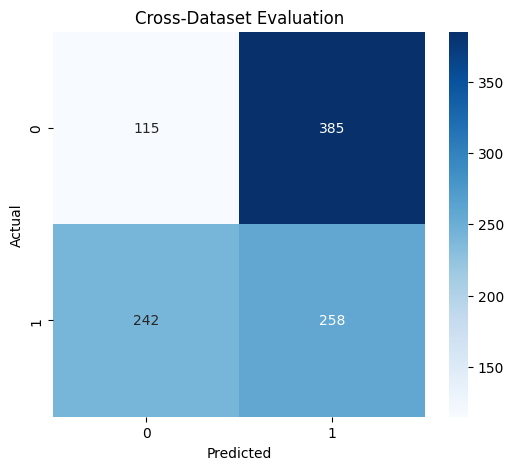

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, rf_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Cross-Dataset Evaluation")

plt.show()